# Hannover Messe Survey Analysis

This notebook analyzes student participation and engagement at the Hannover Messe fair, including:

- Attendance and networking behavior
- Job positions discovered
- Companies visited
- Career fields explored
- Overall specialization distribution

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## Data Quality and Assumptions

**Data Source**: Survey responses from students about their Hannover Messe experience.

**Known Limitations**:
- Some students did not provide complete responses
- Attendance/networking data missing for 2 students (Ihor, Yevhen)
- Position counts missing for 2 students (Tetiana, Yevhen)
- Career field not specified for 1 student (Omar)
- Data collected informally with inconsistent formatting

**Data Cleaning Decisions**:
- Missing boolean values represented as `None`
- Missing numeric values represented as `None` or `NaN`
- AI and Data Science fields merged into single "Data/AI" category
- Empty company lists for non-attendees
- Career fields normalized to consistent categories

**Aggregate Specialization Data** (from separate survey):
- Full-stack: 7 students
- BI/DA: 3 students
- Missing/Both: 10 students (incomplete or ambiguous responses)

## Structured Survey Data

Data structure:
- **attended_messe**: Boolean indicating if student attended the fair (None if unknown)
- **spoke_to_people**: Boolean indicating if student networked at the fair (None if unknown)
- **positions_seen**: Number of job positions discovered (None if unknown)
- **companies_seen**: List of companies visited
- **career_fields_seen**: List of career fields explored
- **notes**: Additional context for ambiguous entries

In [26]:
# Structured Hannover Messe survey data
messe_data_orig = {
    #3	27.04.2026 11:34	27.04.2026 11:35	anonymous	Rowaida		Nein	Nein	0						No one
    "Oleh":{
        "attended_messe": False,
        "spoke_to_people": False,
        "positions_seen": 0,
        "companies_seen": ["Not so much"],
        "career_fields_seen": ["Data Analysis", "AI"],
        "notes": "Did not attend but interested in Data Analyzer field"
    },		
    "Blerina": {
        "attended_messe": False,
        "spoke_to_people": False,
        "positions_seen": 0,
        "companies_seen": [],
        "career_fields_seen": ["Data Analyzer"],
        "notes": "Did not attend but interested in Data Analyzer field"
    },
    "Menjung": {
        "attended_messe": True,
        "spoke_to_people": True,
        "positions_seen": 15,
        "companies_seen": ["Quantum"],
        "career_fields_seen": ["Fullstack"],
        "notes": None
    },
    "Hani": {
        "attended_messe": True,
        "spoke_to_people": True,
        "positions_seen": 7,
        "companies_seen": ["Siemens", "Nestle", "Saudi Arabia", "Adesso"],
        "career_fields_seen": ["Frontend/UX", "BI"],
        "notes": None
    },
    "Hadis": {
        "attended_messe": True,
        "spoke_to_people": True,
        "positions_seen": 3,
        "companies_seen": ["Siemens"],
        "career_fields_seen": ["Web Development"],
        "notes": None
    },
    "Yarema": {
        "attended_messe": True,
        "spoke_to_people": True,
        "positions_seen": 5,
        "companies_seen": ["Microsoft"],
        "career_fields_seen": ["Software Developer"],
        "notes": None
    },
    "Viktoriia": {
        "attended_messe": False,
        "spoke_to_people": False,
        "positions_seen": 0,
        "companies_seen": [],
        "career_fields_seen": ["Marketing", "Data Analytics"],
        "notes": "Did not attend but interested in Marketing and Data Analytics"
    },
    "Andi": {
        "attended_messe": False,
        "spoke_to_people": False,
        "positions_seen": 0,
        "companies_seen": [],
        "career_fields_seen": ["Technician", "System Administrator"],
        "notes": "Did not attend but interested in Technician and System Admin roles"
    },
    "Ihor": {
        "attended_messe": None,
        "spoke_to_people": None,
        "positions_seen": None,
        "companies_seen": ["Bundeswehr", "Siemens"],
        "career_fields_seen": ["System Administrator"],
        "notes": "Attendance/networking status unclear; visited companies listed"
    },
    "Svitlana": {
        "attended_messe": True,
        "spoke_to_people": True,
        "positions_seen": 7,
        "companies_seen": ["AWS", "Agile Robots", "Bosch", "Siemens", "Leibniz Uni"],
        "career_fields_seen": ["AI Engineer", "Data Science"],
        "notes": "AI and Data Science merged in analysis"
    },
    "Sofiia": {
        "attended_messe": True,
        "spoke_to_people": True,
        "positions_seen": 5,
        "companies_seen": ["AWS", "Microsoft", "Bundeswehr", "Food Court"],
        "career_fields_seen": ["FullStack"],
        "notes": None
    },
    "Kareem": {
        "attended_messe": True,
        "spoke_to_people": True,
        "positions_seen": 2,
        "companies_seen": ["SAP", "Microsoft", "Bundeswehr", "Lenovo"],
        "career_fields_seen": ["Frontend"],
        "notes": None
    },
    "Omar": {
        "attended_messe": True,
        "spoke_to_people": True,
        "positions_seen": 2,
        "companies_seen": ["Bundeswehr"],
        "career_fields_seen": [],
        "notes": "Career field not specified"
    },
    "Tetiana": {
        "attended_messe": True,
        "spoke_to_people": True,
        "positions_seen": None,
        "companies_seen": ["Bundeswehr", "BMW"],
        "career_fields_seen": ["Frontend"],
        "notes": "Position count not provided"
    },
    "Yevhen": {
        "attended_messe": None,
        "spoke_to_people": None,
        "positions_seen": None,
        "companies_seen": ["Samsung", "Bundeswehr", "BMW"],
        "career_fields_seen": ["FullStack"],
        "notes": "Attendance/networking/position count unclear; visited companies listed"
    }
}
print(messe_data_orig.keys())
print(len(messe_data_orig.keys()))

dict_keys(['Oleh', 'Blerina', 'Menjung', 'Hani', 'Hadis', 'Yarema', 'Viktoriia', 'Andi', 'Ihor', 'Svitlana', 'Sofiia', 'Kareem', 'Omar', 'Tetiana', 'Yevhen'])
15


In [117]:
from typing import Any
import pandas as pd
df = pd.read_csv('./Sheet1.csv', delimiter=';', encoding='latin-1')
#print(df.head())
#print(df['Name'])

x=df['Name']
sauberx = []
for elem in x:
    if not(pd.isna(elem)):
        sauberx.append(elem)
#ziel['name']='Rowaida'
#print(ziel)
messe_data = messe_data_orig


#ziel.update(messe_data_orig)
print(f'was fehlt aus .csv {sauberx}')
print(f'update {len(ziel.keys())}')
print(ziel.get('Bernard'))


was fehlt aus .csv ['Rowaida', 'Hadis', 'Anton', 'x', 'Bernard', 'Yasser']
update 20
{}


In [124]:

def dataIntegration():
    '''
    '''
    ziel= messe_data_orig.copy()
    print(f'wir haben {len(ziel.keys())}')
    for elem in sauberx:
        ziel[elem] = {}
    return ziel
ziel = dataIntegration()
print(ziel)




print(ziel.keys())
print(f'Zwischenergebnis {ziel}')
print('---TEST---')
### Test ###
print(ziel.get("Blerina"))
print(len(ziel.keys()))

wir haben 15
{'Oleh': {'attended_messe': False, 'spoke_to_people': False, 'positions_seen': 0, 'companies_seen': ['Not so much'], 'career_fields_seen': ['Data Analysis', 'AI'], 'notes': 'Did not attend but interested in Data Analyzer field'}, 'Blerina': {'attended_messe': False, 'spoke_to_people': False, 'positions_seen': 0, 'companies_seen': [], 'career_fields_seen': ['Data Analyzer'], 'notes': 'Did not attend but interested in Data Analyzer field'}, 'Menjung': {'attended_messe': True, 'spoke_to_people': True, 'positions_seen': 15, 'companies_seen': ['Quantum'], 'career_fields_seen': ['Fullstack'], 'notes': None}, 'Hani': {'attended_messe': True, 'spoke_to_people': True, 'positions_seen': 7, 'companies_seen': ['Siemens', 'Nestle', 'Saudi Arabia', 'Adesso'], 'career_fields_seen': ['Frontend/UX', 'BI'], 'notes': None}, 'Hadis': {}, 'Yarema': {'attended_messe': True, 'spoke_to_people': True, 'positions_seen': 5, 'companies_seen': ['Microsoft'], 'career_fields_seen': ['Software Developer'

In [ ]:

#from pickle import 


def dataIntegration():
    '''
    '''
    ziel= messe_data_orig.copy()
    print(f'wir haben {len(ziel.keys())}')
    for elem in sauberx:
        ziel[elem] = {"attended_messe": None,
        "spoke_to_people": None,
        "positions_seen": None,
        "companies_seen": None,
        "career_fields_seen": None,
        "notes": None
        }
    return ziel
ziel = dataIntegration()
print(ziel)




print(ziel.keys())
print(f'Zwischenergebnis {ziel}')
print('---TEST---')
### Test ###
print(ziel.get("Blerina"))
print(len(ziel.keys()))

wir haben 15
{'Oleh': {'attended_messe': False, 'spoke_to_people': False, 'positions_seen': 0, 'companies_seen': ['Not so much'], 'career_fields_seen': ['Data Analysis', 'AI'], 'notes': 'Did not attend but interested in Data Analyzer field'}, 'Blerina': {'attended_messe': False, 'spoke_to_people': False, 'positions_seen': 0, 'companies_seen': [], 'career_fields_seen': ['Data Analyzer'], 'notes': 'Did not attend but interested in Data Analyzer field'}, 'Menjung': {'attended_messe': True, 'spoke_to_people': True, 'positions_seen': 15, 'companies_seen': ['Quantum'], 'career_fields_seen': ['Fullstack'], 'notes': None}, 'Hani': {'attended_messe': True, 'spoke_to_people': True, 'positions_seen': 7, 'companies_seen': ['Siemens', 'Nestle', 'Saudi Arabia', 'Adesso'], 'career_fields_seen': ['Frontend/UX', 'BI'], 'notes': None}, 'Hadis': {'attended_messe': None, 'spoke_to_people': None, 'positions_seen': None, 'companies_seen': None, 'career_fields_seen': None, 'notes': b'N'}, 'Yarema': {'attende

In [31]:
from pandas.core.series import Series


from pandas.core.frame import DataFrame


from typing import Any
import pandas as pd
df = pd.read_csv('./Sheet1.csv', delimiter=';', encoding='latin-1')
#print(df.head())
#print(df['Name'])

x=list(df['Name'])
sauberx = []
for elem in x:
    if not(pd.isna(elem)):
        sauberx.append(elem)
    
print(sauberx)

### Exercise 1 - Pandas ### Schreib eine Python funktion die das df nimmt
def appendCsvToJsonObject2(df: Any, messe_data: Any):
    messe_data=messe_data.copy()
    for elem in sauberx:
        messe_data[elem] = { 
            'attended_messe': (df['Wart ihr auf der Messe?'] == 'Ja'),
            'spoke_to_people': True, # Jetzt
            'career_fields_see': True #Hausaufgabe
        }
    #df #finden wo der Vorname ist
    #messe_data #Vorname]
    return messe_data


#Beispiel:
def appendCsvToJsonObject(df: pd.DataFrame, messe_data: dict) -> dict:
    """
    Fügt CSV-Daten zu messe_data hinzu - NUR für Rowaida
    """
    # Finde Rowaida in der CSV
    rowaida_row: Series | Any | DataFrame = df[df['Name'] == 'Rowaida']
    
    # Erste (und einzige) Zeile nehmen
    row: pd.Series = rowaida_row.iloc[0]

    # Zu messe_data hinzufügen
    messe_data['Rowaida'] = {
        "attended_messe": row['Wart ihr auf der Messe?'] == 'Ja',
        "spoke_to_people": row['Mit Leuten gesprochen?'] == 'Ja',
        "positions_seen": int(row['Wieviele Leute gesehen?']) if pd.notna(row['Wieviele Leute gesehen?']) else 0,
        "companies_seen": [],  # "No one" in CSV
        "career_fields_seen": [],  # Leer in CSV
        "notes": "Added from CSV"
    }
    
    print(f"✅ Rowaida hinzugefügt: {messe_data['Rowaida']}")
    return messe_data

messe_data2 = appendCsvToJsonObject2(df, messe_data_orig)

print(len(messe_data_orig.keys()))
print(messe_data2.keys())

['Rowaida', 'Hadis', 'Anton', 'x', 'Bernard', 'Yasser']
15
dict_keys(['Oleh', 'Blerina', 'Menjung', 'Hani', 'Hadis', 'Yarema', 'Viktoriia', 'Andi', 'Ihor', 'Svitlana', 'Sofiia', 'Kareem', 'Omar', 'Tetiana', 'Yevhen', 'Rowaida', 'Anton', 'x', 'Bernard', 'Yasser'])


In [37]:
data = [{'a': 1, 'b': 2}, {'a': 3, 'b': 4}]
df = pd.DataFrame(data)


In [68]:
import typing

def addingLastNameToListRowaida(dict: typing.List[str])  : 
    #if(dict == 'Rowaida')
    #res = dict+' R. '
    return [name + ' R.' if name == 'Rowaida' else name for name in dict]
    #Liste gehen einmal durch und brauchen len(n)#

In [ ]:
import typing

def addingLastNameToDict(dict: typing.Dict[str,str])  : 
    #if(dict == 'Rowaida')
    #res = dict+' R. '
    res = dict
    res = res['Spalte5/Name'] + ' R.'
    return res
    #Liste gehen einmal durch und brauchen len(n)#

In [ ]:
import pandas as pd

pers1= {'Rowaida':['']}
pers2 = {'Test1': ['']}
testpandas = [pers1,pers2]
print(testpandas)
print()
print(pd.DataFrame(testpandas))

[{'Rowaida': ['']}, {'Test1': ['']}]
  Rowaida Test1
0      []   NaN
1     NaN    []


In [ ]:
import pandas as pd

# 1. DataFrame erstellen
data = {'Name': ['Rowaida', 'test1'], 'Alter': [25, 30]}
df = pd.DataFrame(data)
#Spalte

# 2. In Dictionary umwandeln (orient='records' für Zeilen)
dict_data = df.to_dict(orient='records')

In [ ]:
import pandas as pd

# Die "List of Dicts"
data = [
    {"Name": "Rowaida", "Alter": 25, "Stadt": "Berlin"},
    {"Name": "Test1", "Alter": 30, "Stadt": "Hamburg"},
    {"Name": "Test3", "Alter": 35} # 'Stadt' fehlt hier
]
#Zeile
#data = [{"name:":"Rowaida"}, {"1":25}, {"2":"Berlin"}]

list1 = ["Rowaida", 25, "Berlin"]
#list2 = {"0": "Rowaida"}, {"1":25}, {"2": "Berlin"}
list2 = {0: "Rowaida", 1:  25, 2: "Berlin"}
print(list1[0],)
print(f'list2 {[list2[0],list2[1],list2[2]]}')

# Umwandlung in einen DataFrame
df = pd.DataFrame(data)
print(df)

Rowaida
list2 ['Rowaida', 25, 'Berlin']
      Name  Alter    Stadt
0  Rowaida     25   Berlin
1    Test1     30  Hamburg
2    Test3     35      NaN


In [ ]:
import typing
v1=['test1','test2','Rowaida']
v2 = ['t1','t2','t2','Rowaida']

v1[2]
v2[3]

df: Any = [{'Spalte5/Name': 'Rowaida', 
'Spalte4/E-Mail': '@'}, {'Spalte5/Name': 'Sofiia', 
'Spalte4/E-Mail': '@'}]

indices = list(range(len(df)))
print(indices)  # [0, 1]
#print(addingLastNameToList(v2))
for i in indices:
    print(addingLastNameToDict(df[i]))



dict_simpler: typing.Dict[str,str] = {'Spalte5/Name': 'Rowaida', 
'Spalte4/E-Mail': '@'}

def addingLastNameSimpler(dict: typing.Dict[str,str])  : 
    res = dict['Spalte5/Name']+' R. '
    return res

print(addingLastNameToListRowaida(v2))

#Ziel ist "Rowaida zu bekommen"


TypeError: 'list' object is not callable

In [ ]:
import typing
from typing import List, Dict

# ==================== DATEN ====================
names_list = ['test1', 'test2', 'Rowaida']
people_dict = [
    {'Spalte5/Name': 'Rowaida', 'Spalte4/E-Mail': '@'},
    {'Spalte5/Name': 'Sofiia', 'Spalte4/E-Mail': '@'}
]

print("=" * 60)
print("📋 LIST - 4 Methoden")
print("=" * 60)

# 1️⃣ LIST COMPREHENSION (Pythonic)
result1 = [name + ' R.' if name == 'Rowaida' else name for name in names_list]
print(f"1. List Comprehension: {result1}")

# 2️⃣ FOR LOOP (Klassisch)
result2 = []
for name in names_list:
    if name == 'Rowaida':
        result2.append(name + ' R.')
    else:
        result2.append(name)
print(f"2. For Loop:           {result2}")




# 3️⃣ MAP + LAMBDA (Funktional)
result3 = list(map(lambda x: x + ' R.' if x == 'Rowaida' else x, names_list))
print(f"3. Map + Lambda:       {result3}")



# 4️⃣ FUNKTION (Wiederverwendbar)
def add_r_to_rowaida(names: List[str]) -> List[str]:
    return [name + ' R.' if name == 'Rowaida' else name for name in names]




result4 = add_r_to_rowaida(names_list)
print(f"4. Funktion:           {result4}")

print("\n" + "=" * 60)
print("📚 DICT - 4 Methoden")
print("=" * 60)

# 1️⃣ LIST COMPREHENSION mit DICT UNPACKING (Pythonic)
result5 = [
    {**person, 'Spalte5/Name': person['Spalte5/Name'] + ' R.'} 
    if person['Spalte5/Name'] == 'Rowaida' else person 
    for person in people_dict
]
print(f"1. Dict Unpacking:     {result5[0]['Spalte5/Name']}")

# 2️⃣ FOR LOOP mit COPY (Sicher)
result6 = []
for person in people_dict:
    new_person = person.copy()
    if new_person['Spalte5/Name'] == 'Rowaida':
        new_person['Spalte5/Name'] += ' R.'
    result6.append(new_person)
print(f"2. For Loop + Copy:    {result6[0]['Spalte5/Name']}")

# 3️⃣ MAP + LAMBDA (Funktional)
result7 = list(map(
    lambda p: {**p, 'Spalte5/Name': p['Spalte5/Name'] + ' R.'} 
    if p['Spalte5/Name'] == 'Rowaida' else p,
    people_dict
))
print(f"3. Map + Lambda:       {result7[0]['Spalte5/Name']}")

# 4️⃣ FUNKTION (Wiederverwendbar)
def add_r_to_dict(people: List[Dict[str, str]]) -> List[Dict[str, str]]:
    return [
        {**p, 'Spalte5/Name': p['Spalte5/Name'] + ' R.'} 
        if p['Spalte5/Name'] == 'Rowaida' else p 
        for p in people
    ]



result8 = add_r_to_dict(people_dict)
print(f"4. Funktion:           {result8[0]['Spalte5/Name']}")

print("\n" + "=" * 60)
print("⚡ GESCHWINDIGKEITSVERGLEICH")
print("=" * 60)

import time

# LIST Performance
start = time.time()
for _ in range(10000):
    _ = [name + ' R.' if name == 'Rowaida' else name for name in names_list]
list_time = time.time() - start

# DICT Performance
start = time.time()
for _ in range(10000):
    _ = [{**p, 'Spalte5/Name': p['Spalte5/Name'] + ' R.'} 
         if p['Spalte5/Name'] == 'Rowaida' else p for p in people_dict]
dict_time = time.time() - start

print(f"LIST: {list_time:.4f}s")
print(f"DICT: {dict_time:.4f}s")
print(f"DICT ist {dict_time/list_time:.1f}x langsamer (komplexere Struktur)")

print("\n" + "=" * 60)
print("🎯 BEST PRACTICES")
print("=" * 60)
print("✅ LIST: List Comprehension (einfach, schnell, lesbar)")
print("✅ DICT: Dict Unpacking mit List Comprehension (Pythonic)")
print("❌ Vermeide: map() + lambda (weniger lesbar)")
print("✅ Verwende: Funktionen für Wiederverwendbarkeit")


📋 LIST - 4 Methoden
1. List Comprehension: ['test1', 'test2', 'Rowaida R.']
2. For Loop:           ['test1', 'test2', 'Rowaida R.']


TypeError: 'list' object is not callable

In [ ]:
from typing import Any


import typing

list: typing.List[Any] = [1,2,3,'name'] #fragen
list: typing.List[str] = ['test1', 'test2', 'Rowaida'] #

def addingLastNameToListRowaida(dict: typing.List[str])  : 
    #if(dict == 'Rowaida')
    #res = dict+' R. '
    return [name + ' R.' if name == 'Rowaida' else name for name in dict]
    #Liste gehen einmal durch und brauchen len(n)
print(addingLastNameToListRowaida(list))



dict_simpler: typing.Dict[str,str] = {'Spalte5/Name': 'Rowaida', 
'Spalte4/E-Mail': '@'}

def addingLastNameSimpler(dict: typing.Dict[str,str])  : 
    res = dict['Spalte5/Name']+' R. '
    return res



print(addingLastNameSimpler(dict_simpler))

['test1', 'test2', 'Rowaida R.']
Rowaida R. 


In [ ]:
import typing
#String v = "Test"
#{}

dict: typing.Dict[str,typing.Dict[str,str]] = {'Spalte5/Name': 'Rowaida', 
'Spalte4/E-Mail': {'name':'anonymous'}}
def addingLastName(dict: typing.Dict[str,typing.Dict[str,str]])  : 
    res = dict['Spalte5/Name']['name']+' R. '
    return res

print(dict['Spalte5/Name'])





dict_simpler: typing.Dict[str,str] = {'Spalte5/Name': 'Rowaida', 
'Spalte4/E-Mail': '@'}

def addingLastNameSimpler(dict: typing.Dict[str,str])  : 
    res = dict['Spalte5/Name']+' R. '
    return res



print(addingLastNameSimpler(dict_simpler))
#dict.head()
#print(dict['Spalte5/Name'])

#print(dict.values())
#df = pd.DataFrame(dict)
#df.head()

Rowaida
Rowaida R. 


In [ ]:
from pandas.core.series import Series


from pandas.core.frame import DataFrame


from typing import Any
import pandas as pd
#df = [1,2,3,4,5]
#df = {'Spalte5/Name': 'Rowaida, 'Spalte4/E-Mail': 'anonymous'}

df = pd.read_csv('./Sheet1.csv', delimiter=';', encoding='latin-1')
#print(df.head())
#print(df['Name'])

x=list(df['Name'])
sauberx = []
for elem in x:
    if not(pd.isna(elem)):
        sauberx.append(elem)
    
print(sauberx)

### Exercise 1 - Pandas ### Schreib eine Python funktion die das df nimmt
def appendCsvToJsonObject2(df: Any, messe_data: Any):
    messe_data=messe_data.copy()
    for elem in sauberx:
        messe_data[elem] = { 
            'attended_messe': (df['Wart ihr auf der Messe?'] == 'Ja'),
            'spoke_to_people': True, # Jetzt
            'career_fields_see': True #Hausaufgabe
        }
    #df #finden wo der Vorname ist
    #messe_data #Vorname]
    return messe_data

In [5]:
from pandas import isna


print(df['Name'])
x=list(df['Name'])
print(x)

sauberx = []
for elem in x:
    if not(pd.isna(elem)):
        sauberx.append(elem)
    
sauberx
#print(messe_data[df['Name']])

0         NaN
1         NaN
2     Rowaida
3       Hadis
4       Anton
5           x
6     Bernard
7      Yasser
8         NaN
9         NaN
10        NaN
11        NaN
12        NaN
13        NaN
14        NaN
Name: Name, dtype: object
[nan, nan, 'Rowaida', 'Hadis', 'Anton', 'x', 'Bernard', 'Yasser', nan, nan, nan, nan, nan, nan, nan]


['Rowaida', 'Hadis', 'Anton', 'x', 'Bernard', 'Yasser']

## Convert to DataFrame for Analysis

In [ ]:
df = pd.DataFrame.from_dict(messe_data2, orient='index')
df.head()



,attended_messe,spoke_to_people,positions_seen,companies_seen,career_fields_seen,notes,career_fields_see
Oleh,False,False,0.0,[Not so much],"[Data Analysis, AI]",Did not attend but interested in Data Analyzer...,NaN
Blerina,False,False,0.0,[],[Data Analyzer],Did not attend but interested in Data Analyzer...,NaN
Menjung,True,True,15.0,[Quantum],[Fullstack],None,NaN
Hani,True,True,7.0,"[Siemens, Nestle, Saudi Arabia, Adesso]","[Frontend/UX, BI]",None,NaN
Hadis,0 True 1 True 2 False 3 Tru...,True,NaN,NaN,NaN,NaN,True


In [12]:
# Convert to DataFrame
df = pd.DataFrame.from_dict(messe_data, orient='index')
df.index.name = 'Student'
df = df.reset_index()

# Add derived columns
df['num_companies'] = df['companies_seen'].apply(len)
df['num_career_fields'] = df['career_fields_seen'].apply(len)

print("Hannover Messe Survey Data Overview:")
print(df[['Student', 'attended_messe', 'spoke_to_people', 'positions_seen', 'num_companies', 'num_career_fields']].head(10))

TypeError: object of type 'float' has no len()

## Survey Response Summary

In [ ]:
print("\n=== Hannover Messe Survey Summary ===")
print(f"Total Students Surveyed: {len(df)}")

# Attendance analysis (excluding None values)
attended_known = df['attended_messe'].notna()
attended_yes = df['attended_messe'] == True
print(f"\nAttendance:")
print(f"  Confirmed Attendees: {attended_yes.sum()}")
print(f"  Did Not Attend: {(df['attended_messe'] == False).sum()}")
print(f"  Unknown/Not Reported: {(~attended_known).sum()}")
print(f"  Attendance Rate (of known): {attended_yes.sum() / attended_known.sum() * 100:.1f}%")

# Networking analysis
spoke_known = df['spoke_to_people'].notna()
spoke_yes = df['spoke_to_people'] == True
print(f"\nNetworking:")
print(f"  Spoke to People: {spoke_yes.sum()}")
print(f"  Did Not Network: {(df['spoke_to_people'] == False).sum()}")
print(f"  Unknown/Not Reported: {(~spoke_known).sum()}")
print(f"  Networking Rate (of known): {spoke_yes.sum() / spoke_known.sum() * 100:.1f}%")

# Positions analysis
positions_data = df[df['positions_seen'].notna()]['positions_seen']
print(f"\nJob Positions Discovered:")
print(f"  Average Positions Seen: {positions_data.mean():.1f}")
print(f"  Median Positions Seen: {positions_data.median():.0f}")
print(f"  Range: {positions_data.min():.0f} - {positions_data.max():.0f}")
print(f"  Total Positions Discovered: {positions_data.sum():.0f}")

# Companies analysis
print(f"\nCompanies:")
print(f"  Average Companies per Student: {df['num_companies'].mean():.1f}")
print(f"  Students Who Visited Companies: {(df['num_companies'] > 0).sum()}")


=== Hannover Messe Survey Summary ===
Total Students Surveyed: 14

Attendance:
  Confirmed Attendees: 9
  Did Not Attend: 3
  Unknown/Not Reported: 2
  Attendance Rate (of known): 75.0%

Networking:
  Spoke to People: 9
  Did Not Network: 3
  Unknown/Not Reported: 2
  Networking Rate (of known): 75.0%

Job Positions Discovered:
  Average Positions Seen: 4.2
  Median Positions Seen: 3
  Range: 0 - 15
  Total Positions Discovered: 46

Companies:
  Average Companies per Student: 2.0
  Students Who Visited Companies: 11


## Company Analysis

In [ ]:
# Aggregate all companies
all_companies = []
for data in messe_data.values():
    all_companies.extend(data['companies_seen'])

company_counts = Counter(all_companies)

print("\n=== Most Popular Companies at Hannover Messe ===")
for company, count in company_counts.most_common():
    print(f"{company}: {count} student(s)")


=== Most Popular Companies at Hannover Messe ===
Bundeswehr: 6 student(s)
Siemens: 4 student(s)
Microsoft: 3 student(s)
AWS: 2 student(s)
BMW: 2 student(s)
Quantum: 1 student(s)
Nestle: 1 student(s)
Saudi Arabia: 1 student(s)
Adesso: 1 student(s)
Agile Robots: 1 student(s)
Bosch: 1 student(s)
Leibniz Uni: 1 student(s)
Food Court: 1 student(s)
SAP: 1 student(s)
Lenovo: 1 student(s)
Samsung: 1 student(s)


## Career Field Analysis

In [ ]:
# Aggregate and categorize career fields (merge AI and Data)
career_field_categories = []
for data in messe_data.values():
    for field in data['career_fields_seen']:
        field_lower = field.lower()
        if 'fullstack' in field_lower or 'full-stack' in field_lower:
            career_field_categories.append('FullStack')
        elif 'frontend' in field_lower or 'ux' in field_lower:
            career_field_categories.append('Frontend/UX')
        elif 'data' in field_lower or 'ai' in field_lower or 'bi' in field_lower or 'analytics' in field_lower:
            career_field_categories.append('Data/AI/BI')
        elif 'system' in field_lower or 'admin' in field_lower:
            career_field_categories.append('System Admin')
        elif 'web' in field_lower:
            career_field_categories.append('Web Development')
        elif 'software' in field_lower or 'developer' in field_lower:
            career_field_categories.append('Software Developer')
        elif 'marketing' in field_lower:
            career_field_categories.append('Marketing')
        elif 'technician' in field_lower:
            career_field_categories.append('Technician')
        else:
            career_field_categories.append('Other')

field_counts = Counter(career_field_categories)

print("\n=== Career Fields Explored at Hannover Messe ===")
print("(Note: AI and Data Science merged into Data/AI/BI category)\n")
for field, count in field_counts.most_common():
    print(f"{field}: {count} mention(s)")


=== Career Fields Explored at Hannover Messe ===
(Note: AI and Data Science merged into Data/AI/BI category)

Data/AI/BI: 5 mention(s)
FullStack: 3 mention(s)
Frontend/UX: 3 mention(s)
System Admin: 2 mention(s)
Web Development: 1 mention(s)
Software Developer: 1 mention(s)
Marketing: 1 mention(s)
Technician: 1 mention(s)


## Overall Specialization Distribution

From separate aggregate survey data (total class specialization preferences):

In [ ]:
# Aggregate specialization data from separate survey
specialization_aggregate = {
    'Full-stack': 7,
    'BI/DA': 3,
    'Missing/Both': 10
}

print("\n=== Overall Class Specialization Distribution ===")
print("(From separate aggregate survey)\n")
total_responses = sum(specialization_aggregate.values())
for spec, count in specialization_aggregate.items():
    percentage = (count / total_responses) * 100
    print(f"{spec}: {count} students ({percentage:.1f}%)")
print(f"\nTotal: {total_responses} students")


=== Overall Class Specialization Distribution ===
(From separate aggregate survey)

Full-stack: 7 students (35.0%)
BI/DA: 3 students (15.0%)
Missing/Both: 10 students (50.0%)

Total: 20 students


## Visualizations

NameError: name 'attended_yes' is not defined

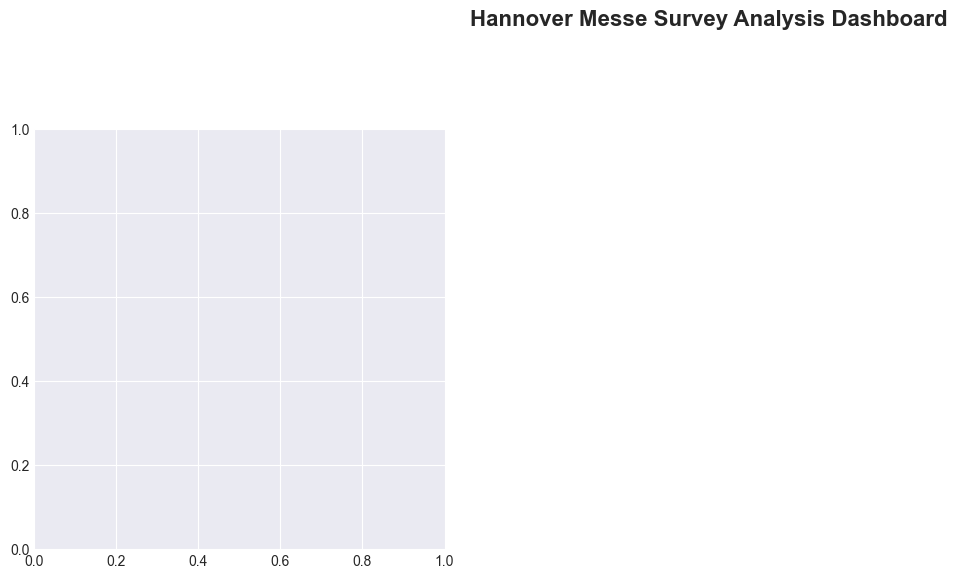

In [11]:
# Create comprehensive visualization dashboard
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Hannover Messe Survey Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Attendance Distribution (Pie Chart)
ax1 = plt.subplot(2, 3, 1)
attendance_data = df['attended_messe'].value_counts(dropna=False)
labels = ['Attended', 'Did Not Attend', 'Unknown']
sizes = [attended_yes.sum(), (df['attended_messe'] == False).sum(), (~attended_known).sum()]
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax1.set_title('Messe Attendance', fontweight='bold')

# 2. Positions Seen by Student (Bar Chart)
ax2 = plt.subplot(2, 3, 2)
positions_df = df[df['positions_seen'].notna()].sort_values('positions_seen', ascending=False)
ax2.barh(positions_df['Student'], positions_df['positions_seen'], color='steelblue')
ax2.set_xlabel('Number of Positions')
ax2.set_title('Job Positions Discovered per Student', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. Top Companies Visited (Horizontal Bar Chart)
ax3 = plt.subplot(2, 3, 3)
top_companies = dict(company_counts.most_common(10))
ax3.barh(list(top_companies.keys()), list(top_companies.values()), color='teal')
ax3.set_xlabel('Number of Students')
ax3.set_title('Top 10 Companies Visited', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Career Fields Explored (Bar Chart)
ax4 = plt.subplot(2, 3, 4)
field_counts_sorted = dict(sorted(field_counts.items(), key=lambda x: x[1], reverse=True))
ax4.bar(field_counts_sorted.keys(), field_counts_sorted.values(), color='coral')
ax4.set_ylabel('Number of Mentions')
ax4.set_title('Career Fields Explored\n(AI/Data merged)', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

# 5. Overall Specialization Distribution (Pie Chart)
ax5 = plt.subplot(2, 3, 5)
spec_labels = list(specialization_aggregate.keys())
spec_sizes = list(specialization_aggregate.values())
spec_colors = ['#3498db', '#e67e22', '#95a5a6']
ax5.pie(spec_sizes, labels=spec_labels, autopct='%1.1f%%', startangle=90, colors=spec_colors)
ax5.set_title('Overall Class Specialization\n(Aggregate Survey)', fontweight='bold')

# 6. Networking vs Positions Discovered (Scatter Plot)
ax6 = plt.subplot(2, 3, 6)
scatter_data = df[(df['spoke_to_people'] == True) & (df['positions_seen'].notna())]
if len(scatter_data) > 0:
    ax6.scatter(scatter_data['num_companies'], scatter_data['positions_seen'], 
               s=100, alpha=0.6, color='darkgreen', edgecolors='black', linewidth=1)
    ax6.set_xlabel('Number of Companies Visited')
    ax6.set_ylabel('Positions Discovered')
    ax6.set_title('Companies Visited vs Positions Found', fontweight='bold')
    ax6.grid(alpha=0.3)
    
    # Add trend line if enough data points
    if len(scatter_data) > 2:
        z = np.polyfit(scatter_data['num_companies'], scatter_data['positions_seen'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(scatter_data['num_companies'].min(), scatter_data['num_companies'].max(), 100)
        ax6.plot(x_trend, p(x_trend), "r--", alpha=0.5, linewidth=2, label='Trend')
        ax6.legend()

plt.tight_layout()
plt.show()

## Additional Visualization: Student Engagement Heatmap

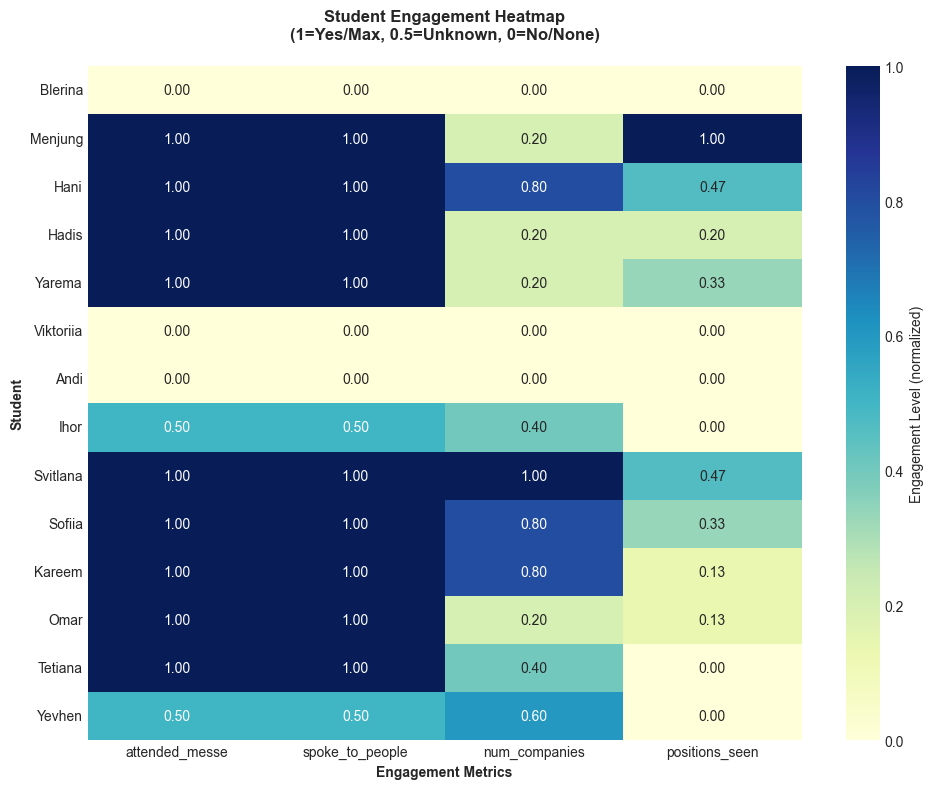

In [ ]:
# Create engagement matrix
engagement_df = df[['Student', 'attended_messe', 'spoke_to_people', 'num_companies', 'positions_seen']].copy()
engagement_df['attended_messe'] = engagement_df['attended_messe'].map({True: 1, False: 0, None: 0.5})
engagement_df['spoke_to_people'] = engagement_df['spoke_to_people'].map({True: 1, False: 0, None: 0.5})
engagement_df['positions_seen'] = engagement_df['positions_seen'].fillna(0)

# Normalize for heatmap
engagement_matrix = engagement_df.set_index('Student')[['attended_messe', 'spoke_to_people', 'num_companies', 'positions_seen']]
engagement_matrix['num_companies'] = engagement_matrix['num_companies'] / engagement_matrix['num_companies'].max() if engagement_matrix['num_companies'].max() > 0 else 0
engagement_matrix['positions_seen'] = engagement_matrix['positions_seen'] / engagement_matrix['positions_seen'].max() if engagement_matrix['positions_seen'].max() > 0 else 0

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(engagement_matrix, annot=True, fmt='.2f', cmap='YlGnBu', 
            cbar_kws={'label': 'Engagement Level (normalized)'}, ax=ax)
ax.set_title('Student Engagement Heatmap\n(1=Yes/Max, 0.5=Unknown, 0=No/None)', fontweight='bold', pad=20)
ax.set_xlabel('Engagement Metrics', fontweight='bold')
ax.set_ylabel('Student', fontweight='bold')
plt.tight_layout()
plt.show()

## Suggested Additional Survey Questions

To improve future data collection and analysis, consider adding these questions:

### High-Priority Questions:

1. **`internship_done_number`**: How many internships have you completed?
   - Type: Integer (0, 1, 2, 3+)
   - Rationale: Quantifies practical experience level

2. **`work_experience_it_in_months`**: Total IT work experience in months?
   - Type: Integer (months)
   - Guidance: Convert part-time to full-time equivalent (e.g., 6 months part-time = 3 months FTE)
   - Rationale: Standardized measure of professional experience


4. **`follow_up_applications`**: How many companies did you apply to after the Messe?
   - Type: Integer
   - Rationale: Measure conversion from networking to action

5. **`interview_invitations`**: How many interview invitations resulted from Messe contacts?
   - Type: Integer
   - Rationale: Measure concrete outcomes of Messe participation

### Additional Valuable Questions:


8. **`salary_expectations`**: Expected starting salary range?
   - Type: Range (e.g., 40-45k, 45-50k, 50-55k, 55k+)
   - Rationale: Align expectations with market reality

9. **`technical_skills_confidence`**: Rate confidence in key technical skills (1-5 scale)
   - Type: Likert scale for multiple skills
   - Rationale: Identify skill gaps and training needs

10. **`messe_satisfaction`**: Overall satisfaction with Messe experience (1-5)?
    - Type: Likert scale
    - Rationale: Evaluate event effectiveness



6. **`preferred_company_size`**: Preferred company size (Startup/SME/Corporate)?
   - Type: Categorical
   - Rationale: Match students with appropriate opportunities

7. **`remote_work_preference`**: Remote work preference (On-site/Hybrid/Remote)?
   - Type: Categorical
   - Rationale: Important for modern job matching
### Data Quality Improvements:

- Use structured forms with validation (dropdowns, number fields)
- Make key fields required (attendance, networking, positions)
- Provide clear examples for ambiguous questions
- Include "Prefer not to answer" option instead of allowing blank responses
- Collect data immediately after the event while memory is fresh

## Export Options

In [ ]:
# Export to CSV (uncomment to use)
# df.to_csv('hannover_messe_survey_data.csv', index=False)

# Export to JSON (uncomment to use)
# import json
# with open('hannover_messe_survey_data.json', 'w', encoding='utf-8') as f:
#     json.dump(messe_data, f, indent=2, ensure_ascii=False)

print("Export options available (uncomment code to use):")
print("- CSV: hannover_messe_survey_data.csv")
print("- JSON: hannover_messe_survey_data.json")

Export options available (uncomment code to use):
- CSV: hannover_messe_survey_data.csv
- JSON: hannover_messe_survey_data.json
